# C4. The harmonic oscillator along the κ-family

Companion notebook to the bachelor's thesis *El formalismo ODM en sistemas híbridos clásico-cuánticos* (Santiago Puyol Miano, Universidad de Zaragoza, 2026).

ODM describes the whole range $\kappa\in[0,1]$ with one generator $\hat{\mathcal H}_{qc}(\kappa)$. For a quadratic potential the κ-dependent terms cancel, and $\hat{\mathcal H}_{qc}(\kappa)=\hbar\hat L$ for every $\kappa$ (D. I. Bondar, R. Cabrera, R. R. Lompay, M. Yu. Ivanov and H. A. Rabitz, *Operational Dynamic Modeling Transcending Quantum and Classical Mechanics*, Phys. Rev. Lett., 2012). This notebook checks the identity for the oscillator and for a general quadratic $U$, and draws the state moving along its energy ellipse, a motion that is the same for every $\kappa$.

**Scope.** The zero-point phase $+\tfrac12\hbar\omega$ of the oscillator is taken from Bondar et al. (2012, Theorem 6) and from N. M. J. Woodhouse, *Geometric Quantization*, ch. 10, and is not derived here. The check concerns only the cancellation of the κ-dependent terms, which needs no half-forms because $\hat L$ is linear in the fibre momenta.

The figure is saved to `figures/oscillator_stills.pdf` and `figures/oscillator_stills.png`.

**Kernel:** SageMath 10.8.

## Notation

- Coordinates $(x,p,\lambda_x,\lambda_p)$ on $\Xi=T^*\mathbb R^2$, with $\hat\lambda_x=-i\partial_x$ and $\hat\lambda_p=-i\partial_p$.
- Liouvillian: $\hat L=(\hat p/m)\hat\lambda_x-U'(\hat x)\hat\lambda_p$. For $U=\tfrac12m\omega^2x^2$, $\hat L_{\mathrm{osc}}=(p/m)\lambda_x-m\omega^2x\,\lambda_p$.
- κ-identification: $\hat x_q=\hat x-\tfrac{\hbar\kappa}{2}\hat\lambda_p$ and $\hat p_q=\hat p+\tfrac{\hbar\kappa}{2}\hat\lambda_x$, with $\kappa\in[0,1]$.

In [1]:
var('x p lambda_x lambda_p hbar kappa m omega')
assume(hbar > 0, kappa >= 0, kappa <= 1, m > 0, omega > 0)

# Liouvillian of the oscillator
L_osc = (p/m)*lambda_x - m*omega^2*x*lambda_p

# kappa-identification
x_q = x - hbar*kappa/2 * lambda_p
p_q = p + hbar*kappa/2 * lambda_x

print("L_osc =", L_osc)
print("x_q   =", x_q)
print("p_q   =", p_q)

L_osc = -lambda_p*m*omega^2*x + lambda_x*p/m
x_q   = -1/2*hbar*kappa*lambda_p + x
p_q   = 1/2*hbar*kappa*lambda_x + p


## 1. $\hat{\mathcal H}_{qc}(\kappa)=\hbar\hat L$ for quadratic $U$

The generator is

$$\hat{\mathcal H}_{qc}(\kappa)=\frac{\hbar}{m}\hat p\hat\lambda_x
  +\frac{1}{\kappa}\Bigl[U\bigl(x-\tfrac{\hbar\kappa}{2}\lambda_p\bigr)-U\bigl(x+\tfrac{\hbar\kappa}{2}\lambda_p\bigr)\Bigr].$$

For quadratic $U$ and $s=\tfrac{\hbar\kappa}{2}\lambda_p$, $U(x-s)-U(x+s)=-2s\,U'(x)=-\hbar\kappa\,\lambda_pU'(x)$. Dividing by $\kappa$ leaves $-\hbar\lambda_pU'(x)$, the potential term of $\hbar\hat L$, with no $\kappa$ left. The exact condition is $U'''=0$.

The cell checks (a) the coefficients of $\hat L_{\mathrm{osc}}$, (b) $\hat{\mathcal H}_{qc}-\hbar\hat L_{\mathrm{osc}}=0$ and $\partial_\kappa\hat{\mathcal H}_{qc}=0$ for the oscillator, and (c) $\hat{\mathcal H}_{qc}=\hbar\hat L$ for $U=\tfrac12m\omega^2x^2+bx+c$.

In [2]:
# (a) L_osc is linear in the fibre momenta, with the expected coefficients
assert diff(L_osc, lambda_x, 2) == 0, "L_osc must be linear in lambda_x"
assert diff(L_osc, lambda_p, 2) == 0, "L_osc must be linear in lambda_p"
coeff_lx = diff(L_osc, lambda_x)   # p/m
coeff_lp = diff(L_osc, lambda_p)   # -m*omega^2*x
assert (coeff_lx - p/m).is_zero(),           f"dL/dlambda_x = {coeff_lx}, expected p/m"
assert (coeff_lp + m*omega^2*x).is_zero(),   f"dL/dlambda_p = {coeff_lp}, expected -m*omega^2*x"
print("OK (a): L_osc is linear in λx, λp with coefficients p/m and −mω²x")

# (b) Generator H_qc(kappa) = (hbar/m)*p*lambda_x + (1/kappa)*[U(x - (hbar*kappa/2)*lambda_p) - U(x + (hbar*kappa/2)*lambda_p)]
U_osc = SR(1)/2 * m * omega^2 * x^2
U_minus = U_osc.subs(x = x - hbar*kappa/2 * lambda_p)
U_plus  = U_osc.subs(x = x + hbar*kappa/2 * lambda_p)
diff_U  = (U_minus - U_plus).expand()   # = -m*omega^2*hbar*kappa*x*lambda_p
H_qc = (hbar/m)*p*lambda_x + diff_U / kappa
H_qc_s = H_qc.simplify_full()           # kappa cancels: (hbar/m)*p*lambda_x - hbar*m*omega^2*x*lambda_p

residual = (H_qc_s - hbar*L_osc).simplify_full()
assert residual.is_zero(), f"H_qc - hbar*L_osc = {residual}"
print("OK (b): Ĥ_qc − ħL̂_osc = 0 for U = ½mω²x²")

kappa_deriv = H_qc_s.diff(kappa).simplify_full()
assert kappa_deriv.is_zero(), f"dH_qc/dkappa = {kappa_deriv}"
print("OK (b): dĤ_qc/dκ = 0")

# (c) Any quadratic polynomial (U''' = 0)
var('b c')  # extra coefficients of a general quadratic
U_gen   = SR(1)/2 * m * omega^2 * x^2 + b*x + c
L_gen   = (p/m)*lambda_x - diff(U_gen, x)*lambda_p   # U' = m*omega^2*x + b
U_gen_m = U_gen.subs(x = x - hbar*kappa/2 * lambda_p)
U_gen_p = U_gen.subs(x = x + hbar*kappa/2 * lambda_p)
H_qc_gen = ((hbar/m)*p*lambda_x + (U_gen_m - U_gen_p).expand()/kappa).simplify_full()
residual_gen = (H_qc_gen - hbar*L_gen).simplify_full()
assert residual_gen.is_zero(), f"general quadratic U: H_qc - hbar*L = {residual_gen}"
print("OK (c): Ĥ_qc = ħL̂ for every quadratic U")

OK (a): L_osc is linear in λx, λp with coefficients p/m and −mω²x
OK (b): Ĥ_qc − ħL̂_osc = 0 for U = ½mω²x²
OK (b): dĤ_qc/dκ = 0
OK (c): Ĥ_qc = ħL̂ for every quadratic U


## 2. Figure: the state along the energy ellipse

With $m=\omega=1$ the energy ellipse is the unit circle. Starting at $(x,p)=(1,0)$ the state moves clockwise, $x(t)=\cos t$, $p(t)=-\sin t$, with period $T=2\pi$. Because $\hat{\mathcal H}_{qc}=\hbar\hat L$ for every $\kappa$, the orbit and the frequency do not depend on $\kappa$. The panels show $t=0$, $T/4$, $T/2$ and $3T/4$.

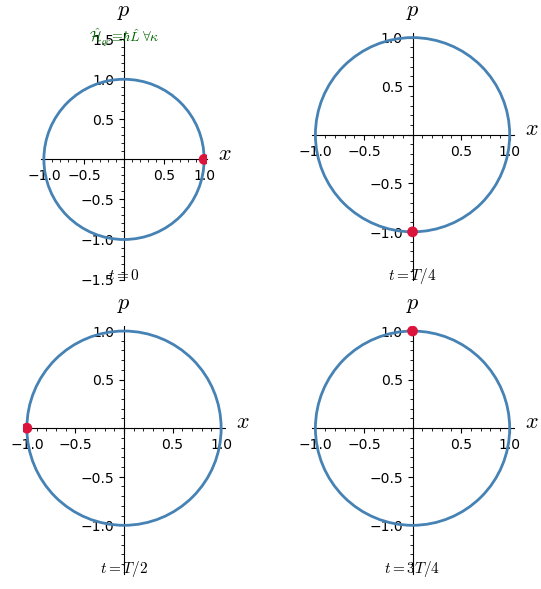

In [3]:
import math

times_num  = [0.0, math.pi/2, math.pi, 3*math.pi/2]
labels_fig = [r'$t=0$', r'$t=T/4$', r'$t=T/2$', r'$t=3T/4$']

panels = []
for tk, lbl in zip(times_num, labels_fig):
    xk = math.cos(tk)   # x(t) = cos(omega*t)   (m = omega = 1, x0 = 1, p0 = 0)
    pk = -math.sin(tk)  # p(t) = -sin(omega*t)

    orb = circle((0, 0), 1.0, color='steelblue', thickness=2,
                 axes_labels=[r'$x$', r'$p$'])
    pos = point((xk, pk), size=60, color='crimson', zorder=5)
    lbl_txt = text(lbl, (0.0, -1.45), fontsize=11, color='black')
    panel = orb + pos + lbl_txt
    panels.append(panel)

# Label the first panel with the identity
kap_note = text(
    r'$\hat{\mathcal{H}}_{qc}\!\equiv\!\hbar\hat{L}\;\forall\kappa$',
    (0.0, 1.52), fontsize=10, color='darkgreen')
panels[0] = panels[0] + kap_note

import os as _os; _os.makedirs('figures', exist_ok=True)
fig = graphics_array([[panels[0], panels[1]], [panels[2], panels[3]]])
fig.save('figures/oscillator_stills.pdf', figsize=[6, 6])
fig.save('figures/oscillator_stills.png', figsize=[6, 6], dpi=150)
fig.show(figsize=[6, 6])

## Final check

In [4]:
import os

gate_residual = (H_qc_s - hbar*L_osc).simplify_full()
assert gate_residual.is_zero(), f"H_qc - hbar*L_osc fails on re-check: {gate_residual}"

assert os.path.exists('figures/oscillator_stills.pdf'), "figures/oscillator_stills.pdf not found"
assert os.path.exists('figures/oscillator_stills.png'), "figures/oscillator_stills.png not found"

print("C4: all checks passed.")

C4: all checks passed.
